## Variational Autoencoder

In [81]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, TensorDataset, Subset
import matplotlib.pyplot as plt
import os
import numpy as np
from torchvision.utils import save_image, make_grid
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
from IPython.core.magic import register_cell_magic
from tqdm import tqdm

In [82]:
@register_cell_magic
def skip(line, cell):
    """Skips the cell if 'True' or no argument is passed."""
    if not line or line.lower() == 'true':
        return
    get_ipython().run_cell(cell)

In [83]:
class CIFAR10_ConvVAE(nn.Module):
    def __init__(self, latent_dim=128):
        super(CIFAR10_ConvVAE, self).__init__()
        
        # 1. ENCODER: Compresses the image into mean and variance vectors
        self.encoder = nn.Sequential(
            # Input: (3, 32, 32)
            nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1), # -> (32, 16, 16)
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1), # -> (64, 8, 8)
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1), # -> (128, 4, 4)
            nn.ReLU(),
            nn.Flatten()
        )
        
        # Latent Space Vectors (Multi-dimensional Gaussian parameters)
        # 128*4*4 = 2048 is the size of the flattened conv features
        self.fc_mu = nn.Linear(2048, latent_dim)
        self.fc_logvar = nn.Linear(2048, latent_dim)
        
        # 2. DECODER: Reconstructs the image from the vectors
        self.decoder_input = nn.Linear(latent_dim, 2048)
        self.decoder = nn.Sequential(
            nn.Unflatten(1, (128, 4, 4)),
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=1), # -> (64, 8, 8)
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1), # -> (32, 16, 16)
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, kernel_size=3, stride=2, padding=1, output_padding=1),  # -> (3, 32, 32)
            nn.Sigmoid() # Keeps pixels between 0 and 1
        )

    def reparameterize(self, mu, logvar):
        """Standard VAE sampling trick to allow backpropagation."""
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        # Pass through encoder
        x_encoded = self.encoder(x)
        mu = self.fc_mu(x_encoded)
        logvar = self.fc_logvar(x_encoded)
        
        # Sample the latent vector z
        z = self.reparameterize(mu, logvar)
        
        # Reconstruct through decoder
        recon_x = self.decoder(self.decoder_input(z))
        return recon_x, mu, logvar

In [84]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out = self.relu(out)
        return out

class CIFAR10_HeavyVAE(nn.Module):
    def __init__(self, latent_dim=512):
        super(CIFAR10_HeavyVAE, self).__init__()
        
        # 1. ENCODER: Using Residual Blocks for high-capacity feature extraction
        self.encoder_conv = nn.Sequential(
            # Input: (3, 32, 32)
            nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            
            ResidualBlock(64, 128, stride=2),  # -> (128, 16, 16)
            ResidualBlock(128, 256, stride=2), # -> (256, 8, 8)
            ResidualBlock(256, 512, stride=2), # -> (512, 4, 4)
            nn.Flatten()
        )
        
        # Latent Space (512*4*4 = 8192)
        self.fc_mu = nn.Linear(8192, latent_dim)
        self.fc_logvar = nn.Linear(8192, latent_dim)
        
        # 2. DECODER: Mirroring the Encoder
        self.decoder_input = nn.Linear(latent_dim, 8192)
        
        self.decoder_conv = nn.Sequential(
            nn.Unflatten(1, (512, 4, 4)),
            
            # Upsampling layers
            nn.ConvTranspose2d(512, 256, kernel_size=4, stride=2, padding=1), # -> (256, 8, 8)
            nn.BatchNorm2d(256),
            nn.ReLU(),
            
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1), # -> (128, 16, 16)
            nn.BatchNorm2d(128),
            nn.ReLU(),
            
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),  # -> (64, 32, 32)
            nn.BatchNorm2d(64),
            nn.ReLU(),
            
            nn.Conv2d(64, 3, kernel_size=3, stride=1, padding=1),
            nn.Sigmoid() 
        )

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        h = self.encoder_conv(x)
        mu, logvar = self.fc_mu(h), self.fc_logvar(h)
        z = self.reparameterize(mu, logvar)
        recon_x = self.decoder_conv(self.decoder_input(z))
        return recon_x, mu, logvar

In [85]:
class CIFAR10_LinearVAE(nn.Module):
    def __init__(self, latent_dim=128):
        super(CIFAR10_LinearVAE, self).__init__()
        
        # CIFAR-10 is 32x32x3 = 3072 pixels
        self.input_dim = 3072
        
        # 1. ENCODER: Flat layers
        self.encoder = nn.Sequential(
            nn.Linear(self.input_dim, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),
            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.ReLU()
        )
        
        # Latent Space mapping
        self.fc_mu = nn.Linear(512, latent_dim)
        self.fc_logvar = nn.Linear(512, latent_dim)
        
        # 2. DECODER: Mirroring the Encoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Linear(512, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),
            nn.Linear(1024, self.input_dim),
            nn.Sigmoid() # Keeps output in [0, 1] range
        )

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        # Flatten the image: (Batch, 3, 32, 32) -> (Batch, 3072)
        x = x.view(-1, self.input_dim)
        
        h = self.encoder(x)
        mu, logvar = self.fc_mu(h), self.fc_logvar(h)
        z = self.reparameterize(mu, logvar)
        
        # Reconstruct and reshape back to image dimensions
        recon_x = self.decoder(z)
        return recon_x.view(-1, 3, 32, 32), mu, logvar

In [86]:
def vae_loss_function(recon_x, x, mu, logvar, beta=0.1):
    # use Mean squared error as reconstruction loss
    mse = F.mse_loss(recon_x, x, reduction='sum')
    # print(f"MSE: {mse}")
    
    # use KL divergence for privacy preserving distribution
    kld_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    # print(f"KLD: {kld_loss}")
    
    return mse + (beta * kld_loss)

In [87]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
transform = transforms.Compose([transforms.ToTensor()])
save_path = "models/conv_heavy_vae_cifar10.pth"

In [88]:
# Loading CIFAR-10 (Images are 32x32x3 = 3072 pixels)
train_set = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)

# # begin testing
# num_local_images = 1000
# indices = np.random.choice(len(train_set), num_local_images, replace=False)

# # 3. Create the subset
# train_set = Subset(train_set, indices)
# #end testing

loader = DataLoader(train_set, batch_size=64, shuffle=True)

In [89]:
vae = CIFAR10_ConvVAE(latent_dim=512).to(device)
# vae = CIFAR10_HeavyVAE(latent_dim=1024).to(device)
epochs = 10

In [90]:

if os.path.exists(save_path):
    print(f"--- Found saved model at {save_path}. Loading weights... ---")
    # Load the state dictionary
    vae.load_state_dict(torch.load(save_path, map_location=device))
    # Crucial: set to eval mode if you are just generating, 
    # or keep in .train() if you want to continue training
    vae.eval()
else:
    print("--- No saved model found. Starting training from scratch... ---")
    
    # Training Loop
    optimizer = optim.Adam(vae.parameters(), lr=1e-3)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5)
    
    vae.train()
    for epoch in range(epochs):
        total_loss = 0
        for images, _ in tqdm(loader):
            images = images.to(device) # No more flattening needed for ConvVAE!
            
            optimizer.zero_grad()
            
            # Unpack the three outputs from your new forward method
            recon_batch, mu, logvar = vae(images)
            
            # Use thes specialized VAE loss function
            loss = vae_loss_function(recon_batch, images, mu, logvar, beta=0.001)
            total_loss += loss.item()
            loss.backward()
            optimizer.step()
        scheduler.step()
        print(f"Epoch: {epoch+1}, Loss: {total_loss:.2f}")
    
    torch.save(vae.state_dict(), save_path)
    print(f"Training complete. Model saved to {save_path}")

--- Found saved model at models/conv_heavy_vae_cifar10.pth. Loading weights... ---


## Reconstruction

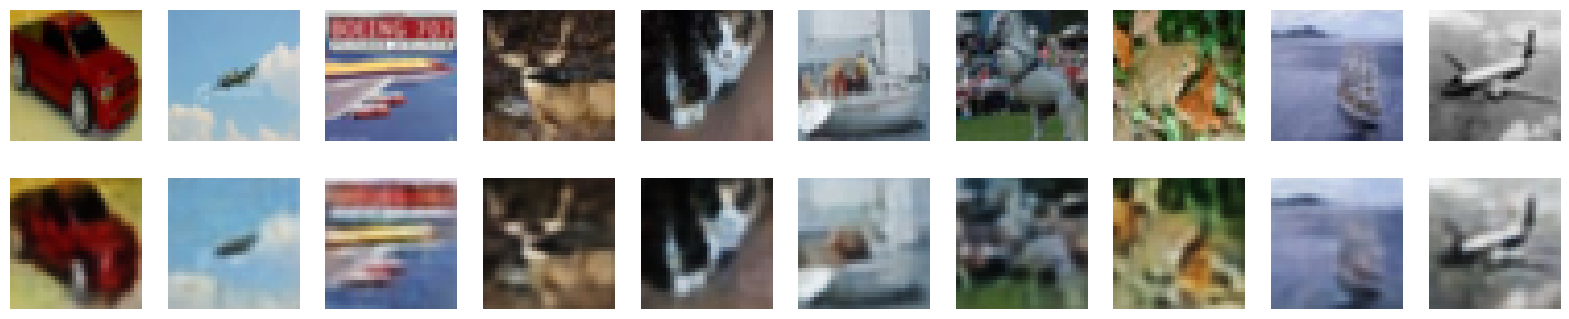

In [91]:
def show_reconstructions(vae, loader, device, n=10):
    vae.eval()
    with torch.no_grad():
        images, _ = next(iter(loader))
        images = images.to(device)
        
        # We only need the first output (recon_batch) from the tuple
        recon_batch, mu, logvar = vae(images)
        
        fig, axes = plt.subplots(2, n, figsize=(n*2, 4))
        for i in range(n):
            # Top row: Original images
            axes[0, i].imshow(images[i].cpu().permute(1, 2, 0))
            axes[0, i].axis('off')
            
            # Bottom row: The "Concealed" versions
            axes[1, i].imshow(recon_batch[i].cpu().permute(1, 2, 0))
            axes[1, i].axis('off')
        
        axes[0, 0].set_ylabel("Original", size='large', fontweight='bold')
        axes[1, 0].set_ylabel("Concealed", size='large', fontweight='bold')
        plt.show()

show_reconstructions(vae, loader, device)

## Image Generation from Latent Space

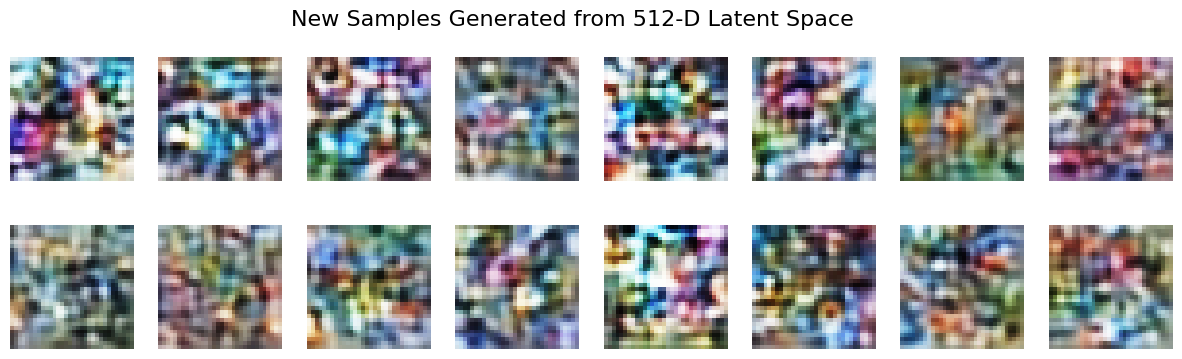

In [92]:
def generate_new_images(vae, device, num_samples=16, latent_dim=128):
    vae.eval()
    with torch.no_grad():
        # 1. Sample from a standard normal distribution (the "Privacy Noise")
        # This simulates picking points from the neighborhood the encoder learned.
        z = torch.randn(num_samples, latent_dim).to(device)
        
        # 2. Pass through the decoder stages
        # We first use the linear layer to expand 'z' back to convolutional shape
        # Then pass it through the ConvTranspose layers.
        generated_flat = vae.decoder_input(z)
        generated_images = vae.decoder(generated_flat)
        
        # 3. Reshape and Visualize
        generated_images = generated_images.cpu()
        
        fig, axes = plt.subplots(2, 8, figsize=(15, 4))
        for i in range(16):
            ax = axes[i // 8, i % 8]
            # Permute to [H, W, C] for plotting
            ax.imshow(generated_images[i].permute(1, 2, 0))
            ax.axis('off')
        
        plt.suptitle(f"New Samples Generated from {latent_dim}-D Latent Space", fontsize=16)
        plt.show()

# Run the generation
generate_new_images(vae, device, num_samples=16, latent_dim=512)

In [93]:
%%skip
def calculate_centroids(vae, loader, device, latent_dim=512):
    vae.eval()
    centroids = torch.zeros(10, latent_dim).to(device)
    counts = torch.zeros(10).to(device)

    print("Mapping latent space centroids...")
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            # We use the 'mu' (mean) vector as the stable identity of the class
            _, mu, _ = vae(images)
            
            for i in range(len(labels)):
                label = labels[i]
                centroids[label] += mu[i]
                counts[label] += 1
    
    # Calculate the average vector for each class
    return centroids / counts.unsqueeze(1)

centroids = calculate_centroids(vae, loader, device, latent_dim=512)

In [94]:
%%skip
def generate_with_labels(vae, centroids, device, num_samples=8, latent_dim=512):
    vae.eval()
    class_names = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
    
    with torch.no_grad():
        # 1. Generate new samples from random noise
        z = torch.randn(num_samples, latent_dim).to(device)
        gen_images = vae.decoder(vae.decoder_input(z)).cpu()
        
        # 2. Find approximate labels
        # Calculate distance from each 'z' to all 10 centroids
        # z: [num_samples, 512], centroids: [10, 512]
        distances = torch.cdist(z, centroids) # Euclidean distance
        
        # Convert distances to a probability distribution (Softmax)
        # We use negative distance because smaller distance = higher probability
        probs = F.softmax(-distances, dim=1)
        
        # 3. Plotting
        fig, axes = plt.subplots(1, num_samples, figsize=(15, 4))
        for i in range(num_samples):
            axes[i].imshow(gen_images[i].permute(1, 2, 0))
            
            # Get the top predicted label and its confidence
            conf, class_idx = torch.max(probs[i], 0)
            label_text = f"{class_names[class_idx]}\n({conf*100:.1f}%)"
            
            axes[i].set_title(label_text, fontsize=10)
            axes[i].axis('off')
            
        plt.tight_layout()
        plt.show()
        
        return gen_images, probs # Returns the "Joint Label" distribution for each image

gen_images, probs = generate_with_labels(vae, centroids, device, num_samples=5, latent_dim=512)

In [95]:
%%skip
def plot_label_distribution(gen_images, probs, num_to_show=5):
    class_names = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
    
    fig, axes = plt.subplots(num_to_show, 2, figsize=(10, num_to_show * 2))
    
    for i in range(num_to_show):
        # 1. Plot the generated image
        axes[i, 0].imshow(gen_images[i].permute(1, 2, 0))
        axes[i, 0].axis('off')
        
        # 2. Plot the probability distribution
        y_pos = range(10)
        axes[i, 1].barh(y_pos, probs[i].cpu().numpy(), align='center', color='skyblue')
        axes[i, 1].set_yticks(y_pos)
        axes[i, 1].set_yticklabels(class_names)
        axes[i, 1].invert_yaxis()  # Labels read top-to-bottom
        axes[i, 1].set_xlim(0, 0.25) # Set a limit to see small differences better
        axes[i, 1].set_xlabel('Probability')

    plt.tight_layout()
    plt.show()

# Pass your generated images and that tensor into this function
plot_label_distribution(gen_images, probs)

## Latent Representation Blending

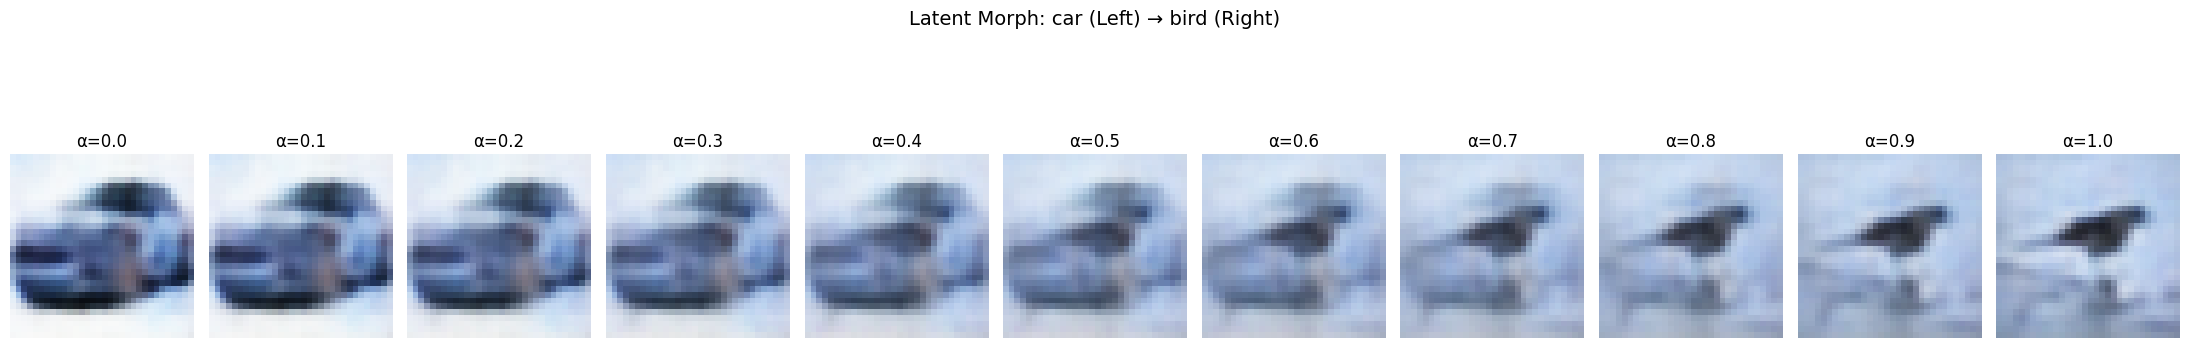

In [96]:
def test_latent_blending(vae, loader, device, num_steps=8):
    vae.eval()
    
    # 1. Grab a batch of images and pick two different ones
    images, labels = next(iter(loader))
    img1 = images[0].to(device).unsqueeze(0) # First image
    img2 = images[1].to(device).unsqueeze(0) # Second image
    
    class_names = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
    label1 = class_names[labels[0]]
    label2 = class_names[labels[1]]

    with torch.no_grad():
        # 2. Get the stable latent identity (mu) for both images
        _, mu1, _ = vae(img1)
        _, mu2, _ = vae(img2)
        
        # 3. Create a range of mixing values from 0 to 1
        # alpha=0 is 100% image 2, alpha=1 is 100% image 1
        alphas = np.linspace(0, 1, num_steps+1)
        
        hybrids = []
        for alpha in alphas:
            # Linear interpolation: blend the two 512-D vectors
            z_mixed = (alpha * mu1) + ((1 - alpha) * mu2)
            
            # Decode the newly created "hybrid" vector
            # We pass it through the linear expander then the conv decoder
            out = vae.decoder(vae.decoder_input(z_mixed))
            hybrids.append(out.cpu().squeeze(0))

    # 4. Visualize the transition
    fig, axes = plt.subplots(1, num_steps+1, figsize=(22, 4))
    plt.suptitle(f"Latent Morph: {label2} (Left) → {label1} (Right)", fontsize=14, y=1.05)
    
    for i in range(num_steps+1):
        # Convert [C, H, W] to [H, W, C] for plotting
        img_to_plot = hybrids[i].permute(1, 2, 0).numpy()
        axes[i].imshow(img_to_plot)
        axes[i].set_title(f"α={alphas[i]:.1f}")
        axes[i].axis('off')
        
    plt.tight_layout()
    plt.show()

# To run it, ensure your vae and loader are defined:
test_latent_blending(vae, loader, device, num_steps=10)

## CNN Classification Model

In [97]:
class SimpleClassifier(nn.Module):
    def __init__(self):
        super(SimpleClassifier, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

In [98]:
def train_classifier(model, train_loader, device, epochs=10):
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()
    model.train()
    
    for epoch in range(epochs):
        correct = 0
        total = 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
        print(f"Epoch {epoch+1}: Acc {100.*correct/total:.2f}%")
    return model

def train_soft_classifier(model, train_loader, device, epochs=10):
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    
    # BCEWithLogitsLoss handles multi-class probability distributions
    # It is much more stable than standard CrossEntropy for soft labels.
    criterion = nn.BCEWithLogitsLoss() 
    
    model.train()
    for epoch in range(epochs):
        total_loss = 0
        correct = 0
        total = 0
        
        for images, joint_labels in train_loader:
            images, joint_labels = images.to(device), joint_labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            
            # 1. Calculate loss between the model's logits and your soft labels
            loss = criterion(outputs, joint_labels)
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
            
            # 2. Calculate "Argmax Accuracy"
            # We compare the model's top guess to the most dominant class in the soup
            _, predicted = outputs.max(1)
            _, target_class = joint_labels.max(1)
            
            total += joint_labels.size(0)
            correct += predicted.eq(target_class).sum().item()
            
        avg_loss = total_loss / len(train_loader)
        acc = 100. * correct / total
        print(f"Epoch {epoch+1}: Loss: {avg_loss:.4f} | Proxy Acc: {acc:.2f}%")
        
    return model

In [99]:
def evaluate_classifier(model, test_loader, device, name="Model"):
    model.eval()
    all_preds = []
    all_labels = []
    correct = 0
    total = 0
    
    class_names = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
    
    print(f"\n--- Evaluating {name} on Clean Test Set ---")
    
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            
            # Get predictions (the index of the highest logit)
            _, predicted = outputs.max(1)
            
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
            # Store for confusion matrix
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    accuracy = 100. * correct / total
    print(f"Overall Accuracy: {accuracy:.2f}%")
    
    # 2. Confusion Matrix Visualization
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'Confusion Matrix: {name}')
    plt.show()
    
    return accuracy

In [100]:
def create_blended_dataset(vae, loader, device):
    vae.eval()
    all_imgs = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            # Encode images
            _, mu, _ = vae(images)
            
            # Create a shifted version to blend with (Mix image i with image i+1)
            mu_shifted = torch.roll(mu, shifts=1, dims=0)
            labels_shifted = torch.roll(labels, shifts=1, dims=0)
            
            # 50/50 Blend
            z_mixed = 0.5 * mu + 0.5 * mu_shifted
            
            # Decode the hybrid
            blended_imgs = vae.decoder(vae.decoder_input(z_mixed))
            
            all_imgs.append(blended_imgs.cpu())
            # We'll keep the original labels for simplicity
            all_labels.append(labels) 
            
    return DataLoader(TensorDataset(torch.cat(all_imgs), torch.cat(all_labels)), batch_size=64, shuffle=True)

In [101]:
def create_pro_blended_dataset(vae, loader, device):
    vae.eval()
    all_imgs = []
    all_soft_labels = []
    
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            # 1. Get both Mean and Log-Variance
            _, mu, logvar = vae(images)
            sigma = torch.exp(0.5 * logvar)
            
            # 2. Create shifted versions (the "partners" for blending)
            mu2 = torch.roll(mu, shifts=1, dims=0)
            sigma2 = torch.roll(sigma, shifts=1, dims=0)
            labels2 = torch.roll(labels, shifts=1, dims=0)
            
            # 3. Calculate Joint Mean and Joint Variance
            mu_joint = 0.5 * mu + 0.5 * mu2
            # Variance adds in quadrature: Var(0.5X + 0.5Y) = 0.25*Var(X) + 0.25*Var(Y)
            sigma_joint = torch.sqrt(0.25 * sigma**2 + 0.25 * sigma2**2)
            
            # 4. Sample a point from the NEW Joint Distribution (The "Privacy Sample")
            eps = torch.randn_like(sigma_joint)
            z_joint = mu_joint + sigma_joint * eps
            
            # 5. Decode
            blended_imgs = vae.decoder(vae.decoder_input(z_joint))
            
            # 6. Create Joint Soft Labels (One-Hot encoding)
            # Creates a [Batch, 10] matrix of 0.5 and 0.5
            soft_label1 = F.one_hot(labels, num_classes=10).float()
            soft_label2 = F.one_hot(labels2, num_classes=10).float()
            joint_labels = 0.5 * soft_label1 + 0.5 * soft_label2
            
            all_imgs.append(blended_imgs.cpu())
            all_soft_labels.append(joint_labels.cpu())
            
    return DataLoader(TensorDataset(torch.cat(all_imgs), torch.cat(all_soft_labels)), batch_size=64, shuffle=True)

In [102]:
def create_k_blended_dataset(vae, loader, device, k=3):
    vae.eval()
    all_imgs = []
    all_soft_labels = []
    
    with torch.no_grad():
        for images, labels in loader:
            batch_size = images.size(0)
            images = images.to(device)
            
            # 1. Get Latent Stats
            _, mu, logvar = vae(images)
            sigma_sq = torch.exp(logvar) # Working in variance space
            
            # 2. Generate k sets of random weights (Dirichlet-like)
            # weights shape: [k, batch_size, 1]
            weights = torch.rand(k, batch_size, 1).to(device)
            weights = weights / weights.sum(dim=0, keepdim=True)
            
            # 3. Initialize Joint Stats
            mu_joint = torch.zeros_like(mu)
            var_joint = torch.zeros_like(sigma_sq)
            label_joint = torch.zeros(batch_size, 10).to(device)
            
            # 4. Accumulate the soup
            for i in range(k):
                # We roll the batch to get k different images for every slot
                m = torch.roll(mu, shifts=i, dims=0)
                v = torch.roll(sigma_sq, shifts=i, dims=0)
                l = torch.roll(labels, shifts=i, dims=0)
                
                w = weights[i] # [batch_size, 1]
                
                mu_joint += w * m
                var_joint += (w**2) * v # Variance scales by weight squared
                
                # Convert hard label to one-hot and weight it
                one_hot = F.one_hot(l, num_classes=10).float()
                label_joint += w * one_hot

            # 5. Sample from the Joint Distribution
            sigma_joint = torch.sqrt(var_joint)
            eps = torch.randn_like(sigma_joint)
            z_soup = mu_joint + sigma_joint * eps
            
            # 6. Decode the "Soup"
            soup_imgs = vae.decoder(vae.decoder_input(z_soup))
            
            all_imgs.append(soup_imgs.cpu())
            all_soft_labels.append(label_joint.cpu())
            
    return DataLoader(TensorDataset(torch.cat(all_imgs), torch.cat(all_soft_labels)), batch_size=64, shuffle=True)

In [103]:
%%skip
print("Preparing Blended Dataset...")
blended_loader = create_blended_dataset(vae, loader, device)
pro_blended_loader = create_pro_blended_dataset(vae, loader, device)

normal_images, normal_labels = next(iter(loader))
blended_images, blended_labels = next(iter(blended_loader))
pro_blended_images, pro_blended_labels = next(iter(pro_blended_loader))

In [104]:
%%skip
save_image(normal_images, "normal.png")
save_image(blended_images, "blended.png")
save_image(pro_blended_images, "pro_blended.png")

In [105]:
k = 2
k_blended_loader = create_k_blended_dataset(vae, loader, device, k=k)

normal_images, normal_labels = next(iter(loader))
k_blended_images, k_blended_labels = next(iter(k_blended_loader))

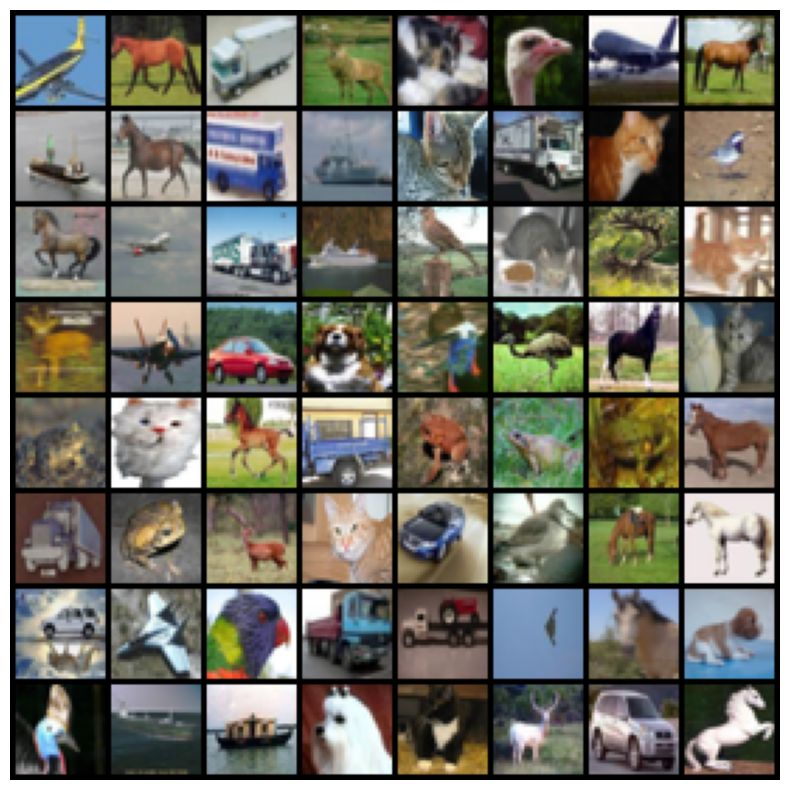

In [106]:
normal_grid = make_grid(normal_images, nrow=8)
plt.figure(figsize=(10, 10))
plt.imshow(normal_grid.permute(1, 2, 0).cpu().numpy())
plt.axis('off')
plt.show()

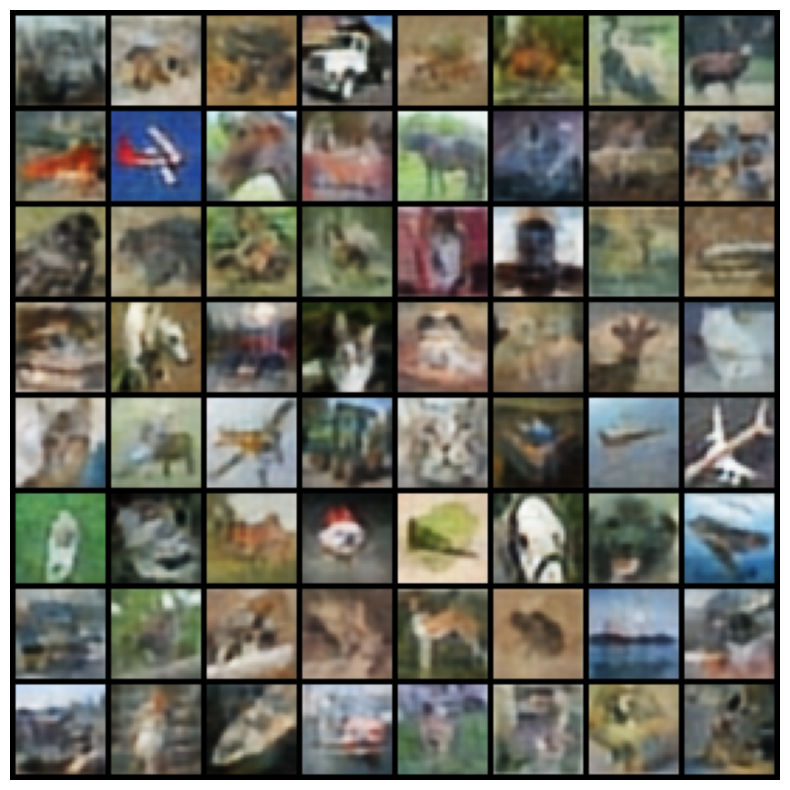

In [107]:
k_blended_grid = make_grid(k_blended_images, nrow=8)
plt.figure(figsize=(10, 10))
plt.imshow(k_blended_grid.permute(1, 2, 0).cpu().numpy())
plt.axis('off')
plt.show()

In [108]:
# save_image(normal_images, f"{k}_normal.png")
# save_image(blended_images, f"{k}_blended.png")

## Train the CNN model

In [109]:
# Train normal model
normal_model = SimpleClassifier()
normal_model = train_classifier(normal_model, loader, device, epochs=10)

Epoch 1: Acc 47.43%
Epoch 2: Acc 60.63%
Epoch 3: Acc 66.48%
Epoch 4: Acc 69.66%
Epoch 5: Acc 72.49%
Epoch 6: Acc 74.99%
Epoch 7: Acc 77.08%
Epoch 8: Acc 79.37%
Epoch 9: Acc 81.46%
Epoch 10: Acc 83.53%


In [110]:
test_set = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
test_loader = DataLoader(test_set, batch_size=64, shuffle=False)


--- Evaluating Normal on Clean Test Set ---
Overall Accuracy: 70.72%


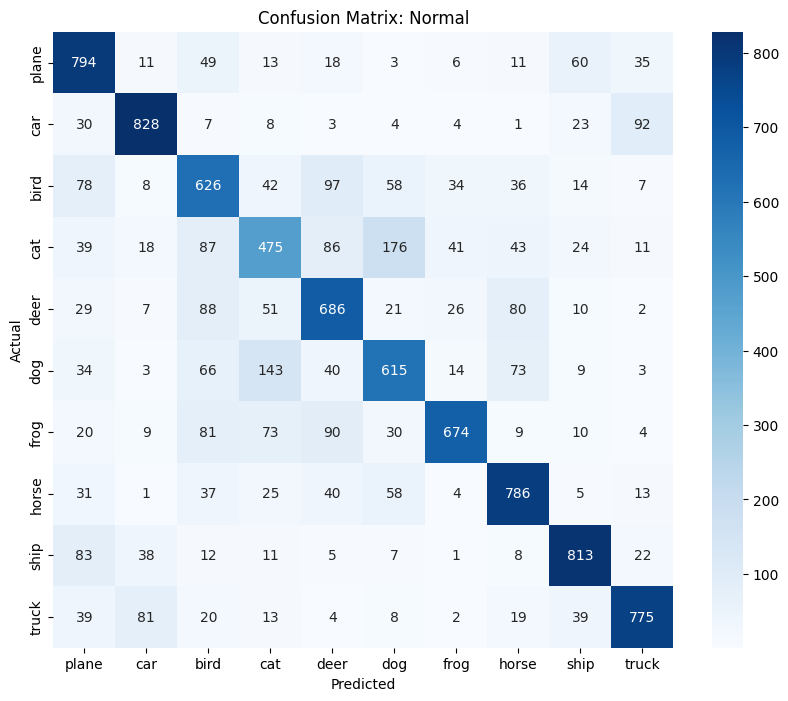

70.72

In [111]:
evaluate_classifier(normal_model, test_loader, device, "Normal")

In [112]:
# Train normal model
blended_model = SimpleClassifier()
blended_model = train_soft_classifier(blended_model, k_blended_loader, device, epochs=20)

Epoch 1: Loss: 0.2924 | Proxy Acc: 31.85%
Epoch 2: Loss: 0.2667 | Proxy Acc: 43.48%
Epoch 3: Loss: 0.2577 | Proxy Acc: 47.90%
Epoch 4: Loss: 0.2505 | Proxy Acc: 50.93%
Epoch 5: Loss: 0.2450 | Proxy Acc: 53.51%
Epoch 6: Loss: 0.2408 | Proxy Acc: 55.12%
Epoch 7: Loss: 0.2371 | Proxy Acc: 56.60%
Epoch 8: Loss: 0.2335 | Proxy Acc: 58.30%
Epoch 9: Loss: 0.2299 | Proxy Acc: 59.81%
Epoch 10: Loss: 0.2267 | Proxy Acc: 61.28%
Epoch 11: Loss: 0.2234 | Proxy Acc: 62.58%
Epoch 12: Loss: 0.2200 | Proxy Acc: 64.03%
Epoch 13: Loss: 0.2170 | Proxy Acc: 65.16%
Epoch 14: Loss: 0.2144 | Proxy Acc: 66.31%
Epoch 15: Loss: 0.2115 | Proxy Acc: 67.32%
Epoch 16: Loss: 0.2090 | Proxy Acc: 68.54%
Epoch 17: Loss: 0.2066 | Proxy Acc: 69.38%
Epoch 18: Loss: 0.2039 | Proxy Acc: 70.28%
Epoch 19: Loss: 0.2017 | Proxy Acc: 71.26%
Epoch 20: Loss: 0.1994 | Proxy Acc: 72.17%



--- Evaluating Blended on Clean Test Set ---
Overall Accuracy: 61.01%


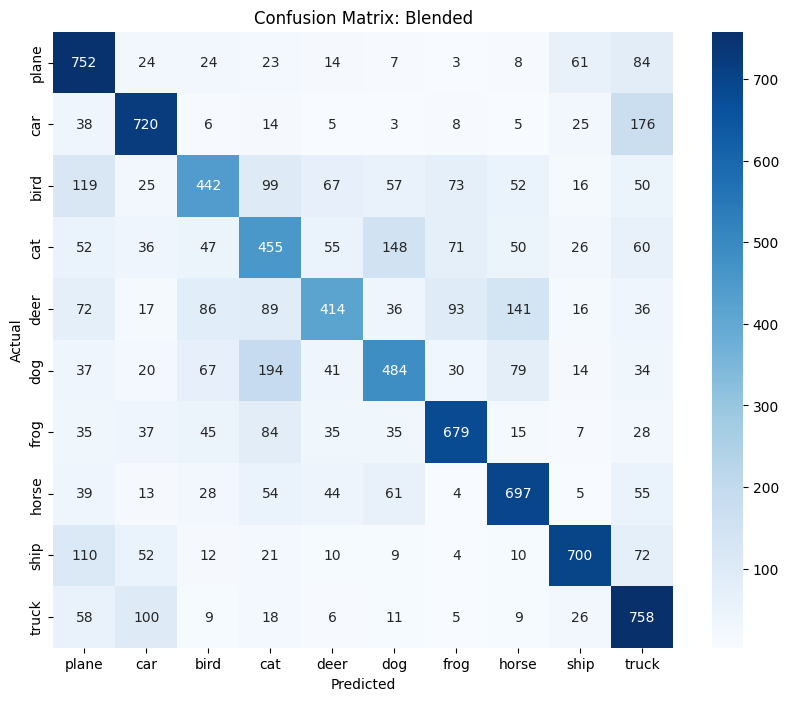

61.01

In [113]:
evaluate_classifier(blended_model, test_loader, device, "Blended")